<a href="https://colab.research.google.com/github/nilanjana310/-GAN-ai-based-image-generation/blob/main/assing4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Sat May  2 05:41:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install pycocotools matplotlib pillow tqdm

In [ ]:
import os
import random
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from collections import Counter
from pycocotools.coco import COCO

In [ ]:
if not os.path.exists("coco"):
    os.makedirs("coco/images", exist_ok=True)
    os.makedirs("coco/annotations", exist_ok=True)

    !wget -q http://images.cocodataset.org/zips/val2017.zip
    !wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip

    !unzip -q val2017.zip -d coco/images
    !unzip -q annotations_trainval2017.zip -d coco/

In [ ]:
ann_file = 'coco/annotations/captions_val2017.json'
coco = COCO(ann_file)

img_ids = coco.getImgIds()
all_ann_ids = coco.getAnnIds()

print("Total Images:", len(img_ids))
print("Total Captions:", len(all_ann_ids))


loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Total Images: 5000
Total Captions: 25014



Caption Statistics:
Min: 7
Max: 50
Average: 10.439673782681698


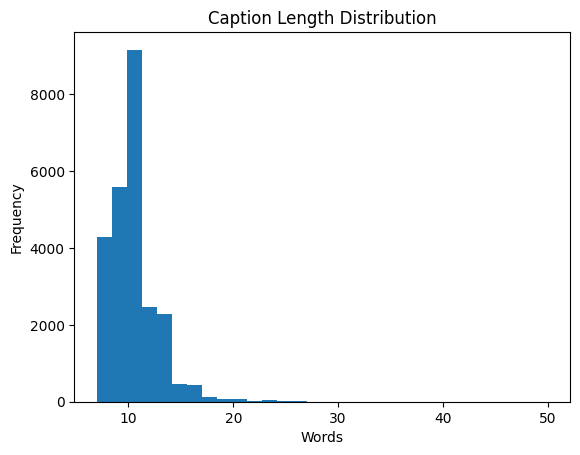

In [ ]:
anns = coco.loadAnns(all_ann_ids)

caption_lengths = [len(a['caption'].split()) for a in anns]

print("\nCaption Statistics:")
print("Min:", np.min(caption_lengths))
print("Max:", np.max(caption_lengths))
print("Average:", np.mean(caption_lengths))

plt.hist(caption_lengths, bins=30)
plt.title("Caption Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

100%|██████████| 1000/1000 [00:00<00:00, 657826.85it/s]


Image Resolution:
Avg Width: 570.443
Avg Height: 486.428


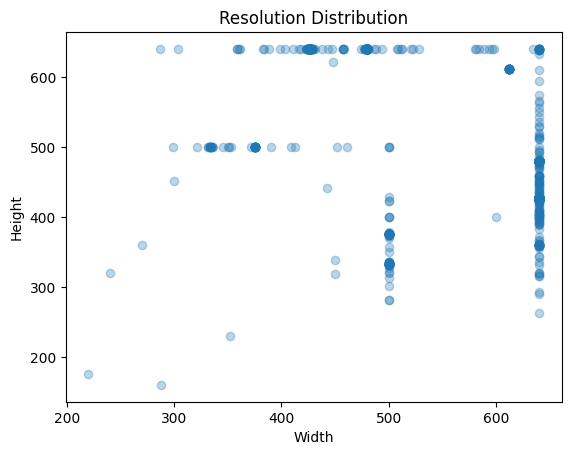

In [ ]:
widths, heights = [], []

for img_id in tqdm(img_ids[:1000]):
    img = coco.loadImgs(img_id)[0]
    widths.append(img['width'])
    heights.append(img['height'])

print("\nImage Resolution:")
print("Avg Width:", np.mean(widths))
print("Avg Height:", np.mean(heights))

plt.scatter(widths, heights, alpha=0.3)
plt.title("Resolution Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

In [ ]:
from collections import Counter

word_counter = Counter()

for ann_id in tqdm(ann_ids[:5000]):
    ann = coco.loadAnns(ann_id)[0]
    words = ann['caption'].lower().split()
    word_counter.update(words)

print("\nTop 20 Most Common Words:")
print(word_counter.most_common(20))

100%|██████████| 5/5 [00:00<00:00, 11348.23it/s]


Top 20 Most Common Words:
[('a', 9), ('toilet', 5), ('and', 3), ('with', 3), ('small', 2), ('in', 2), ('sink', 2), ('closed', 1), ('cramped', 1), ('space.', 1), ('tan', 1), ('combination', 1), ('room.', 1), ('this', 1), ('is', 1), ('an', 1), ('advanced', 1), ('control', 1), ('panel.', 1), ('close-up', 1)]


In [ ]:
import json

sample_data = []

for img_id in img_ids[:10]:
    img_info = coco.loadImgs(img_id)[0]
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    sample_data.append({
        "image": img_info['file_name'],
        "captions": [ann['caption'] for ann in anns]
    })

with open("sample_coco_data.json", "w") as f:
    json.dump(sample_data, f, indent=4)

print("\nSample data saved!")


Sample data saved!


In [ ]:
print("Total Images:", len(img_ids))
print("Total Captions:", len(ann_ids))

Total Images: 5000
Total Captions: 5


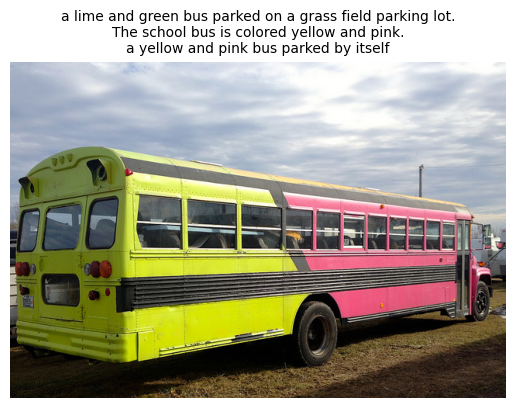

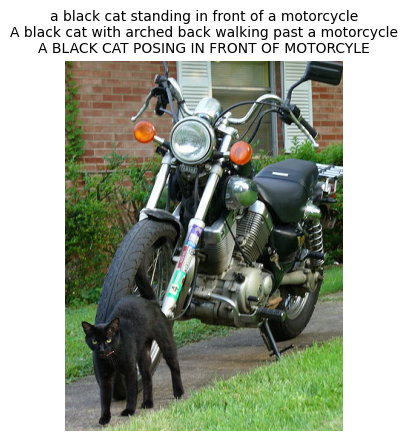

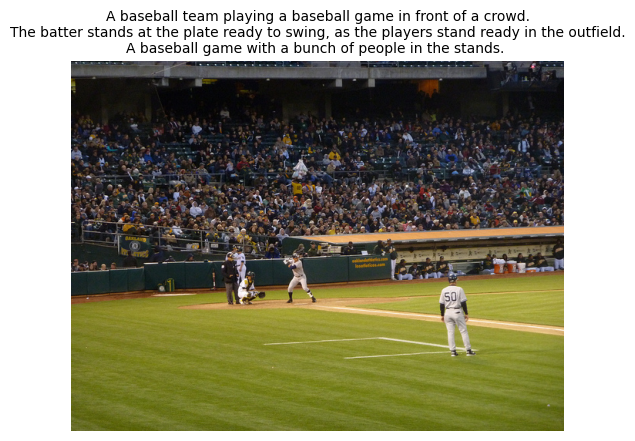

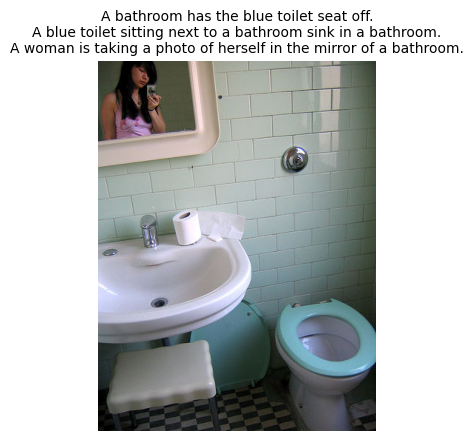

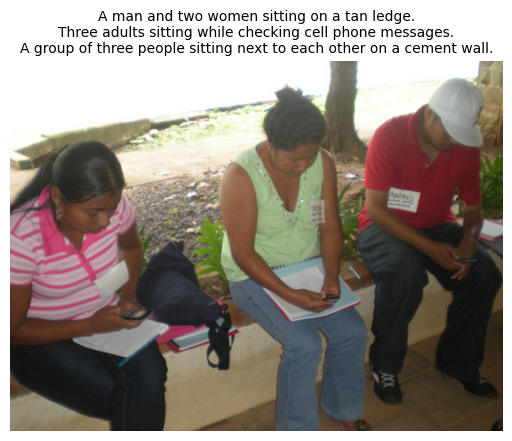

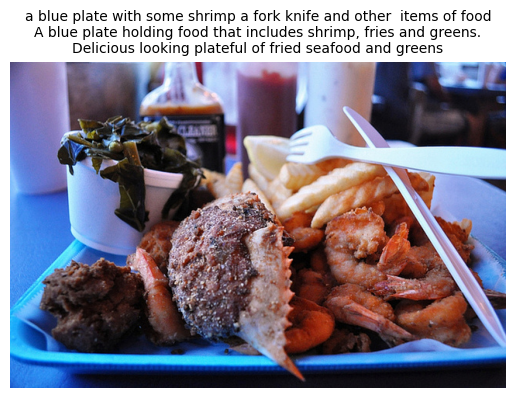

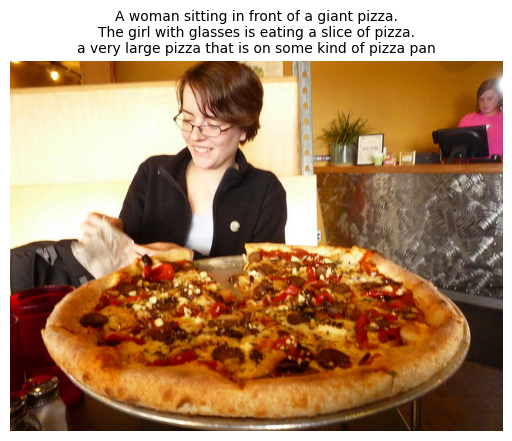

In [ ]:
import random
import os

def show_samples(num_samples=5):
    for _ in range(num_samples):
        img_id = random.choice(img_ids)
        img_info = coco.loadImgs(img_id)[0]

        img_path = os.path.join("coco/images/val2017", img_info['file_name'])
        image = Image.open(img_path)

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        captions = [ann['caption'] for ann in anns]

        plt.imshow(image)
        plt.axis('off')
        plt.title("\n".join(captions[:3]), fontsize=10)
        plt.show()

show_samples(7)